In [1]:
!pip -q install -U protobuf sentencepiece tokenizers "huggingface_hub>=0.24.0" "diffusers>=0.30.0" "transformers==4.57.6" accelerate safetensors pillow tqdm bitsandbytes

In [2]:
!pip install einops torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 33.4 MB/s eta 0:00:00a 0:00:01


In [1]:
import torch

try:
    # Create two small BF16 tensors on the H200
    a = torch.randn(1024, 1024, device='cuda', dtype=torch.bfloat16)
    b = torch.randn(1024, 1024, device='cuda', dtype=torch.bfloat16)
    
    # Perform the operation that failed previously
    c = torch.matmul(a, b)
    
    print("Verification Success: BF16 Matrix Multiplication completed without error.")
except Exception as e:
    print(f"Verification Failed: {e}")

Verification Success: BF16 Matrix Multiplication completed without error.


In [2]:

# Option A: interactive (prompts in notebook)
# Fix dependency mismatch


from huggingface_hub import login
login()  # paste your HF token when prompted

# Option B: non-interactive (set token explicitly)
# import os
# os.environ["HF_TOKEN"] = "hf_..."   # <-- put your token here (or load from env/secret store)
# login(token=os.environ["HF_TOKEN"], add_to_git_credential=True)

# Option C: if you already did `huggingface-cli login` in terminal, you can skip login().


In [3]:
import os, json, time, random, glob, math
from dataclasses import dataclass
from typing import Dict, List, Any, Optional, Tuple
from PIL import Image
from tqdm.auto import tqdm

import torch

# Speed knobs (safe defaults for high-VRAM GPU boxes)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [4]:
CIFAR10_CLASSES = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

@dataclass
class GenConfig:
    jsonl_paths: List[str]
    out_root: str = "./cifar10_synth"
    samples_per_class: int = 2000
    seed: int = 123

    # Generate high-res, then downsample to CIFAR-10 32x32
    gen_width: int = 512
    gen_height: int = 512
    cifar_size: int = 32

    # Inference
    steps: int = 30
    guidance: float = 7.5

    # Performance
    batch_size: int = 100           # increase on high VRAM (e.g., 8, 12, 16)
    num_gpus: Optional[int] = None # None = use all visible GPUs

CFG = GenConfig(
    jsonl_paths=["airplane.jsonl"],   # <-- change me
    out_root="./cifar10_synth_huanyuan",
    samples_per_class=200,
    seed=123,
    gen_width=512, gen_height=512,
    cifar_size=32,
    steps=30, guidance=7.5,
    batch_size=10,                 # <-- tune for your VRAM
    num_gpus=None,                # use all GPUs by default
)

os.makedirs(CFG.out_root, exist_ok=True)

In [5]:
def read_jsonl(path: str):
    with open(path, "r", encoding="utf-8") as f:
        for ln, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except json.JSONDecodeError as e:
                raise ValueError(f"Bad JSON on {path}:{ln}: {e}")

def load_rows(paths: List[str]) -> List[Dict[str, Any]]:
    rows = []
    for p in paths:
        rows.extend(list(read_jsonl(p)))
    return rows

def normalize_label(s: str) -> str:
    return (s or "").strip().lower()

def group_by_class(rows: List[Dict[str, Any]]) -> Dict[str, List[Dict[str, Any]]]:
    out = {c: [] for c in CIFAR10_CLASSES}
    other: Dict[str, int] = {}
    for r in rows:
        cls = normalize_label(r.get("class_label"))
        if cls in out:
            out[cls].append(r)
        else:
            other[cls] = other.get(cls, 0) + 1
    if other:
        print("Warning: non-CIFAR class_label(s) found (ignored):")
        for k, v in other.items():
            print(f"  - {k!r}: {v}")
    return out

def stable_sample(items: List[Dict[str, Any]], k: int, rng: random.Random) -> List[Dict[str, Any]]:
    if len(items) <= k:
        return list(items)
    idx = list(range(len(items)))
    rng.shuffle(idx)
    return [items[i] for i in idx[:k]]

rows = load_rows(CFG.jsonl_paths)
by_cls = group_by_class(rows)

rng = random.Random(CFG.seed)
sampled: Dict[str, List[Dict[str, Any]]] = {}
for c in CIFAR10_CLASSES:
    sampled[c] = stable_sample(by_cls[c], CFG.samples_per_class, rng)
    print(f"{c:>10}: sampled {len(sampled[c])} / available {len(by_cls[c])}")

  airplane: sampled 200 / available 1000
automobile: sampled 0 / available 0
      bird: sampled 0 / available 0
       cat: sampled 0 / available 0
      deer: sampled 0 / available 0
       dog: sampled 0 / available 0
      frog: sampled 0 / available 0
     horse: sampled 0 / available 0
      ship: sampled 0 / available 0
     truck: sampled 0 / available 0


In [6]:
def safe_filename(s: str) -> str:
    s = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in (s or ""))
    s = s.strip("_")
    return (s[:120] or "item")

def resize_to_cifar(img: Image.Image, size: int) -> Image.Image:
    if img.mode != "RGB":
        img = img.convert("RGB")
    return img.resize((size, size), resample=Image.Resampling.LANCZOS)

def build_tasks(sampled_by_class: Dict[str, List[Dict[str, Any]]], backend_name: str, cfg: GenConfig):
    tasks = []
    for cls, items in sampled_by_class.items():
        for r in items:
            prompt = r.get("prompt") or ""
            neg = r.get("negative_prompt") or None
            pid = r.get("id", None)

            base = f"{cfg.seed}|{backend_name}|{cls}|{pid}|{prompt}"
            seed = abs(hash(base)) % (2**31 - 1)

            stem = safe_filename(str(pid)) if pid is not None else safe_filename(prompt[:80])

            # Modified paths here to put class folders directly under cifar_hires and cifar32
            hires_dir = os.path.join(cfg.out_root, "cifar_hires", cls)
            cifar_dir = os.path.join(cfg.out_root, "cifar32", cls)

            hires_path = os.path.join(hires_dir, f"{stem}_{seed}.png")
            cifar_path = os.path.join(cifar_dir, f"{stem}_{seed}.png")

            tasks.append({
                "class_label": cls,
                "prompt_id": pid,
                "prompt": prompt,
                "negative_prompt": neg,
                "seed": int(seed),
                "hires_path": hires_path,
                "cifar_path": cifar_path,
            })
    return tasks

def chunked(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

In [7]:
# ============================================================
# Load HF pipeline" 
# ============================================================

import torch
from transformers import AutoModelForCausalLM

# ---- Backend config ----
BACKEND_KIND = "HunyuanImage-3"
BACKEND_NAME = "HunyuanImage-3-NF4-v2"
MODEL_ID = "EricRollei/HunyuanImage-3-NF4-v2"

# SD3.5: bfloat16 is typical on high-VRAM GPUs
DTYPE = torch.bfloat16
device = "cuda:0"

assert torch.cuda.is_available(), "CUDA GPU not available."

pipe = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    trust_remote_code=True, 
    dtype="auto"
)

pipe = pipe.to(device)
#pipe.set_progress_bar_config(disable=True)

# Optional speed/memory tweaks (safe to try; ignore if unavailable)
try:
    pipe.enable_xformers_memory_efficient_attention()
except Exception:
    pass
try:
    if hasattr(pipe, "vae"):
        pipe.vae.enable_slicing()
        pipe.vae.enable_tiling()
except Exception:
    pass

print("Loaded:", MODEL_ID, "dtype:", DTYPE, "device:", device)


config.json: 0.00B [00:00, ?B/s]

configuration_hunyuan.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/EricRollei/HunyuanImage-3-NF4-v2:
- configuration_hunyuan.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


hunyuan.py: 0.00B [00:00, ?B/s]

tokenizer_wrapper.py: 0.00B [00:00, ?B/s]

...

model-00010-of-00011.safetensors:   0%|          | 0.00/4.80G [00:00<?, ?B/s]

model-00011-of-00011.safetensors:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/11 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/937 [00:00<?, ?B/s]

Loaded: EricRollei/HunyuanImage-3-NF4-v2 dtype: torch.bfloat16 device: cuda:0


[DEBUG] Calling pipe.generate_image(...)
[DEBUG] prompt='A photorealistic airplane on a runway at golden hour, 35mm, shallow depth of field'
[DEBUG] seed=123 size=(512,512) steps=20 stream=True
Model input info:
       token shape: torch.Size([2, 1051])
        context[0]: <|startoftext|>A photorealistic airplane on a runway at golden hour, 35mm, shallow depth of field<boi><img_size_1024><img_ratio_9><timestep>[<img>]{1024}<eoi>
              seed: [123]
        image_size: ['512x512']
       infer_steps: 20
    guidance_scale: 5.0
        flow_shift: 3.0
--------------------------------------------------


  0%|          | 0/20 [00:00<?, ?it/s]

[DEBUG] Returned type: <class 'PIL.Image.Image'>
[DEBUG] Matched Case A: single PIL Image returned


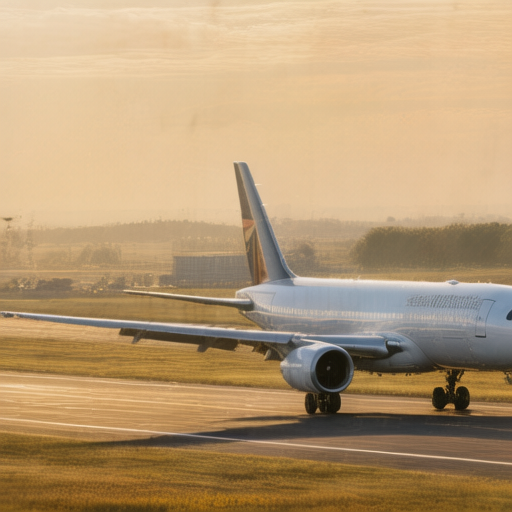

In [11]:
import torch

# ---- make sure tokenizer is loaded (your earlier fix) ----
if hasattr(pipe, "load_tokenizer"):
    pipe.load_tokenizer(MODEL_ID)

pipe.eval()

@torch.inference_mode()
def generate_one(
    prompt: str,
    seed: int = 42,
    width: int = 512,
    height: int = 512,
    stream: bool = True,
    diff_infer_steps: int = 50,
    verbose: int = 1,
    debug: bool = True,
    **kwargs,
):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if not hasattr(pipe, "generate_image"):
        raise RuntimeError("Model has no generate_image().")

    if debug:
        print("[DEBUG] Calling pipe.generate_image(...)")
        print(f"[DEBUG] prompt={prompt!r}")
        print(f"[DEBUG] seed={seed} size=({width},{height}) steps={diff_infer_steps} stream={stream}")

    out = pipe.generate_image(
        prompt=prompt,
        seed=seed,
        image_size=(width, height),
        stream=stream,
        diff_infer_steps=diff_infer_steps,
        verbose=verbose,
        **kwargs,
    )

    if debug:
        print("[DEBUG] Returned type:", type(out))

    # ---- normalize return types with clear prints ----
    # Case A: returns a PIL Image
    if hasattr(out, "save"):
        if debug:
            print("[DEBUG] Matched Case A: single PIL Image returned")
        return out

    # Case B: returns (cot_text, samples)
    if isinstance(out, tuple) and len(out) == 2:
        if debug:
            print("[DEBUG] Matched Case B: (cot_text, samples) tuple returned")
        cot_text, samples = out
        if debug:
            print("[DEBUG] cot_text type:", type(cot_text))
            print("[DEBUG] samples type:", type(samples))
            if isinstance(samples, (list, tuple)):
                print("[DEBUG] samples length:", len(samples))
                if len(samples) > 0:
                    print("[DEBUG] samples[0] type:", type(samples[0]))
        if isinstance(samples, (list, tuple)) and len(samples) > 0:
            return samples[0]
        return samples

    # Case C: returns list/tuple of images
    if isinstance(out, (list, tuple)) and len(out) > 0:
        if debug:
            print("[DEBUG] Matched Case C: list/tuple returned; taking first element")
            print("[DEBUG] first element type:", type(out[0]))
        return out[0]

    # Case D: returns dict
    if isinstance(out, dict):
        if debug:
            print("[DEBUG] Matched Case D: dict returned; keys:", list(out.keys()))
        for k in ("image", "images", "result", "samples"):
            if k in out:
                v = out[k]
                if debug:
                    print(f"[DEBUG] Using key '{k}' with type:", type(v))
                return v[0] if isinstance(v, (list, tuple)) else v

    raise TypeError(f"Unexpected return type from generate_image(): {type(out)}")

# ---- example ----
prompt = "A photorealistic airplane on a runway at golden hour, 35mm, shallow depth of field"
img = generate_one(prompt, seed=123, width=512, height=512, diff_infer_steps=20, debug=True)

img.save("hunyuan_one.png")
img

In [13]:
import inspect
print("Has generate_image:", hasattr(pipe, "generate_image"))
if hasattr(pipe, "generate_image"):
    print("generate_image signature:", inspect.signature(pipe.generate_image))

Has generate_image: True
generate_image signature: (prompt, seed=None, image_size='auto', use_system_prompt=None, system_prompt=None, bot_task=None, stream=False, **kwargs)


In [ ]:
import os, json, time
from tqdm.auto import tqdm
import torch

tasks = build_tasks(sampled, BACKEND_NAME, CFG)

meta_path = os.path.join(CFG.out_root, f"metadata_{BACKEND_NAME}.jsonl")
os.makedirs(CFG.out_root, exist_ok=True)

if hasattr(pipe, "load_tokenizer"):
    pipe.load_tokenizer(MODEL_ID)

pipe.eval()

def _generate_batch_or_fallback(batch):
    """
    Try true batching (list prompts) first.
    If not supported by this repo, fall back to per-image.
    Returns: list[PIL.Image]
    """
    prompts = [t["prompt"] for t in batch]
    seeds   = [int(t["seed"]) for t in batch]

    # ---- Attempt batch call ----
    try:
        print(f"[DEBUG] Trying BATCH call with n={len(batch)} ...")

        # Seeding: some repos accept list of seeds; some ignore seed arg.
        # We'll still set a base seed for determinism-ish.
        torch.manual_seed(seeds[0])
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seeds[0])

        out = pipe.generate_image(
            prompt=prompts,  # <-- list
            seed=seeds,      # <-- list (if unsupported, will error)
            image_size=(CFG.gen_width, CFG.gen_height),
            diff_infer_steps=getattr(CFG, "steps", 50),
            stream=True,
            verbose=0,
        )

        # Normalize output
        # 1) list/tuple of images
        if isinstance(out, (list, tuple)) and len(out) == len(batch) and hasattr(out[0], "save"):
            print("[DEBUG] Batch supported: returned list/tuple of PIL images.")
            return list(out)

        # 2) dict with images
        if isinstance(out, dict):
            for k in ("images", "samples", "result"):
                if k in out and isinstance(out[k], (list, tuple)) and len(out[k]) == len(batch):
                    if hasattr(out[k][0], "save"):
                        print(f"[DEBUG] Batch supported: returned dict['{k}'] list of PIL images.")
                        return list(out[k])

        # 3) something else: treat as failure
        raise TypeError(f"Batch call returned unexpected type/shape: {type(out)}")

    except Exception as e:
        print(f"[DEBUG] Batch NOT supported (or failed). Falling back to per-image. Reason: {repr(e)}")

    # ---- Fallback per-image ----
    imgs = []
    with torch.inference_mode():
        for t in batch:
            seed = int(t["seed"])
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

            img = pipe.generate_image(
                prompt=t["prompt"],
                seed=seed,
                image_size=(CFG.gen_width, CFG.gen_height),
                diff_infer_steps=getattr(CFG, "steps", 50),
                stream=True,
                verbose=0,
            )
            if not hasattr(img, "save"):
                raise TypeError(f"Expected PIL Image in fallback, got {type(img)}")
            imgs.append(img)
    return imgs

print(f"Total tasks: {len(tasks)} | batch_size={CFG.batch_size}")
pbar = tqdm(total=len(tasks))

with open(meta_path, "a", encoding="utf-8") as mf:
    for batch in chunked(tasks, CFG.batch_size):
        batch = [t for t in batch if not (os.path.exists(t["hires_path"]) and os.path.exists(t["cifar_path"]))]

        if not batch:
            pbar.update(CFG.batch_size)
            continue

        for t in batch:
            os.makedirs(os.path.dirname(t["hires_path"]), exist_ok=True)
            os.makedirs(os.path.dirname(t["cifar_path"]), exist_ok=True)

        t0 = time.time()
        try:
            images = _generate_batch_or_fallback(batch)

            for tsk, img in zip(batch, images):
                img_rgb = img.convert("RGB") if getattr(img, "mode", None) != "RGB" else img
                img_rgb.save(tsk["hires_path"], format="PNG", optimize=True)

                img32 = resize_to_cifar(img_rgb, CFG.cifar_size)
                img32.save(tsk["cifar_path"], format="PNG", optimize=True)

                rec = {
                    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
                    "backend": BACKEND_NAME,
                    "kind": BACKEND_KIND,
                    "model_id": MODEL_ID,
                    "class_label": tsk["class_label"],
                    "hires_path": tsk["hires_path"],
                    "cifar32_path": tsk["cifar_path"],
                    "seed": tsk["seed"],
                    "steps": getattr(CFG, "steps", None),
                    "guidance": getattr(CFG, "guidance", None),
                    "gen_width": CFG.gen_width,
                    "gen_height": CFG.gen_height,
                    "cifar_size": CFG.cifar_size,
                    "prompt_id": tsk["prompt_id"],
                    "prompt": tsk["prompt"],
                    "negative_prompt": tsk.get("negative_prompt", ""),
                    "elapsed_sec_batch": round(time.time() - t0, 3),
                }
                mf.write(json.dumps(rec, ensure_ascii=False) + "\n")
            mf.flush()

        except Exception as e:
            for tsk in batch:
                mf.write(json.dumps({
                    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
                    "backend": BACKEND_NAME,
                    "kind": BACKEND_KIND,
                    "model_id": MODEL_ID,
                    "class_label": tsk.get("class_label"),
                    "prompt_id": tsk.get("prompt_id"),
                    "prompt": tsk.get("prompt"),
                    "error": repr(e),
                }, ensure_ascii=False) + "\n")
            mf.flush()

        pbar.update(len(batch))

pbar.close()
print(f"Done. Images in: {os.path.join(CFG.out_root, BACKEND_NAME)}")
print(f"Metadata appended to: {meta_path}")

Total tasks: 200 | batch_size=10


  0%|          | 0/200 [00:00<?, ?it/s]

[DEBUG] Trying BATCH call with n=10 ...


  0%|          | 0/30 [00:00<?, ?it/s]

[DEBUG] Batch NOT supported (or failed). Falling back to per-image. Reason: AssertionError('len(t)=2 != len(idx)=20')


...

[DEBUG] Batch NOT supported (or failed). Falling back to per-image. Reason: AssertionError('len(t)=2 != len(idx)=20')


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
!nvidia-smi


Mon Jan 19 20:36:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:00:08.0 Off |                    0 |
| N/A   38C    P0             48W /  300W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import torch
from transformers import AutoModelForCausalLM

BACKEND_KIND = "hunyuan_image_3"
BACKEND_NAME = "hunyuanimage3"
MODEL_ID = "./HunyuanImage-3"  # local folder

kwargs = dict(
    attn_implementation="sdpa",      # use "flash_attention_2" if installed
    trust_remote_code=True,
    torch_dtype="auto",
    device_map="auto",              # parallel loading across your GPUs
    moe_impl="eager",               # use "flashinfer" if installed
)

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **kwargs)
model.load_tokenizer(MODEL_ID)

# Helpful for reproducibility / speed
model.eval()
torch.set_grad_enabled(False)

print("Loaded:", MODEL_ID)
# If available, inspect placement
if hasattr(model, "hf_device_map"):
    print("hf_device_map (sample):", list(model.hf_device_map.items())[:10])


You are using a model of type hunyuan_image_3_moe to instantiate a model of type Hunyuan. This is not supported for all configurations of models and can yield errors.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/32 [00:00<?, ?it/s]

Loaded: ./HunyuanImage-3
hf_device_map (sample): [('vae', 0), ('vision_model', 0), ('vision_aligner', 0), ('timestep_emb', 0), ('patch_embed', 0), ('time_embed', 0), ('final_layer', 0), ('time_embed_2', 0), ('model.wte', 0), ('model.layers.0', 0)]


In [ ]:
torch.cuda.empty_cache()

In [ ]:
!nvidia-smi